# Fourier Transfrom - A Visual Introduction

<ul>
<li><b>This notebook is based on this amazing video by 3Blue1Brown, explaining the quite widely ungrasped topic of Fourier Transform, in a very intuitive, visually stimulating and satisfying way.</b></li>
<li>This notebook implements the method explained in the video, the center of the mass idea, along with plotting various graphs that pop up on our way.</li>
<li>Highly popular Python libraries Numpy and Matplotlib were used.

In [37]:
from IPython.display import HTML
HTML('<iframe width="950" height="520" src="https://www.youtube.com/embed/spUNpyF58BY" frameborder="1" allowfullscreen></iframe>')

# 1. Generating the signal
We will be using an exponential decay signal e^{-\alpha t} (with \alpha = 2.0) as the input signal.

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()

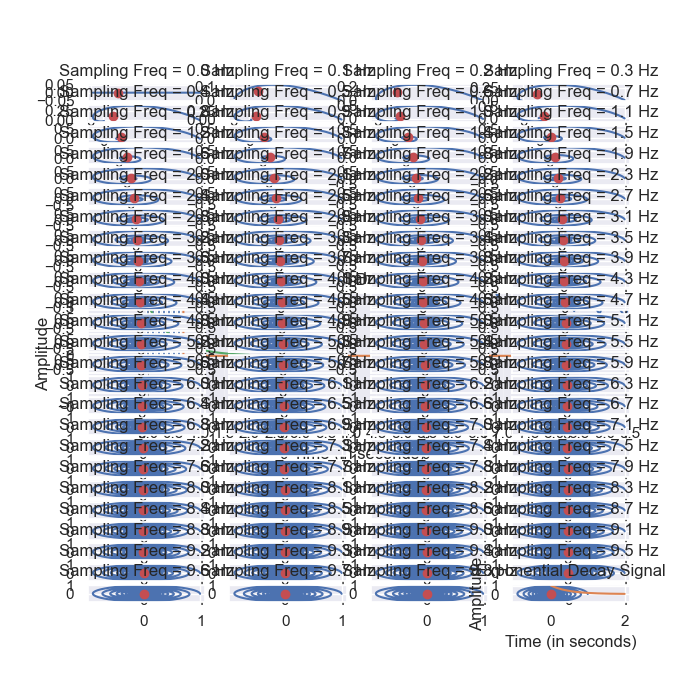

In [39]:
# f = 3.0
# t = np.arange(0,2,0.001) 

# cos_wave = np.cos(2*np.pi*f*t)
# # cos_wave = 2*m.cos(2*np.pi*f*t) + 5*m.cos(2*np.pi*f*2*t)

# plt.rcParams["figure.figsize"] = (12,4)
# plt.plot(t,cos_wave)
# plt.title("Cosine Wave with 3 Hz frequency")
# plt.ylabel("Amplitude")
# plt.xlabel('Time (in seconds)');

# 指数衰减信号
t = np.arange(0, 2, 0.001)
alpha = 2.0  # 衰减系数
exp_signal = np.exp(-alpha * t)

plt.rcParams["figure.figsize"] = (12, 4)
plt.plot(t, exp_signal)
plt.title("Exponential Decay Signal")
plt.ylabel("Amplitude")
plt.xlabel('Time (in seconds)')
plt.grid(True)
plt.show()

# 2. Warping the input signal wave around

Just to summarise the idea put forth in the video, we need to try warping the input signal graph for a number of sampling frequencies and then by keeping the track of the x-coordinate of the center of mass, considering the warped graph as a piece made of metal wire, we can estimate the frequencies present in the input signal.<br>
The range for frequency search is kept here as 0 to 10 Hz.

In [40]:
r_cord = []  # List to store length of the amplitude of the signal
min_freq_range = 0.0  #Start frequency
max_freq_range = 10.0  #End frequency
sf_list = np.arange(min_freq_range, max_freq_range, 0.1)
for sf in sf_list:
    r_cord.append( [(exp_signal[i], t[i]*sf*2*np.pi) for i in range(len(t)) ] )

举个简单的例子理解这段代码
1. 第一层循环：遍历每个 sf，生成一组 (幅值, 角度)
公式：
theta = t[i] * sf * 2π
amp = exp_signal[i]
① 当 sf = 0.5 Hz
逐个 i 计算：
i=0：amp=1，θ = 0.0 * 0.5 * 2π = 0
i=1：amp=2，θ = 0.1 * 0.5 * 2π ≈ 0.314159
i=2：amp=3，θ = 0.2 * 0.5 * 2π ≈ 0.628319
这一组打包成列表：
[(1, 0), (2, 0.314159), (3, 0.628319)]
② 当 sf = 1.0 Hz
i=0：amp=1，θ = 0.0 * 1.0 * 2π = 0
i=1：amp=2，θ = 0.1 * 1.0 * 2π ≈ 0.628319
i=2：amp=3，θ = 0.2 * 1.0 * 2π ≈ 1.256637
这一组打包成列表：
[(1, 0), (2, 0.628319), (3, 1.256637)]
1. r_cord 完整结构（二维嵌套列表）
把上面两组依次 append 进 r_cord，最终：
python
r_cord = [
    # 第0层元素：对应 sf=0.5Hz 的全部时间点(amp,θ)对
    [(1, 0), (2, 0.314159), (3, 0.628319)],
    # 第1层元素：对应 sf=1.0Hz 的全部时间点(amp,θ)对
    [(1, 0), (2, 0.628319), (3, 1.256637)]
]
1. 层级命名，彻底分清维度
外层维度（一级索引）：频率维度
r_cord[k] → 取出第 k 个试探频率 sf_list[k] 对应的全部点对
例：r_cord[0] 就是 0.5Hz 的所有 (幅值，角度)
内层维度（二级索引）：时间采样点维度
r_cord[k][i] → 第 k 个频率、第 i 个时间点的第 i 个时间点的二元组 (amp, theta)
例：r_cord[1][2] = (3, 1.256637) 代表 sf=1Hz、t=0.2s 处的幅值与极角
二元组内部：(幅值 amp, 极角 theta)
r_cord[k][i][0] = 信号幅度 exp_signal [i]
r_cord[k][i][1] = 旋转相位角 t [i]・sf・2π

In [41]:
x_cord , y_cord = [], []
for l in range(len(r_cord)):
    x_cord.append( [amp*np.cos(theta) for (amp,theta) in r_cord[l]] )
    y_cord.append( [amp*np.sin(theta) for (amp,theta) in r_cord[l]] )

Below cell plots all the beautiful curves that pop up while doing this for each value of the sampling frequency in our list.<br>
Will take a little bit of time to execute, because the number of plots may be high, and once every plot is made, only then the whole figure pops up.<br>
Totally worth the wait !! The <b>Red dot</b> denotes the Center of Mass of the graph. 

In [42]:
mean_list = []

plt.rcParams["figure.figsize"] = (15,110)
for l in range(len(r_cord)):
    plt.subplot(int(len(r_cord)/4)+1, 4, int(l+1))
    plt.plot(x_cord[l], y_cord[l])
    plt.plot(np.mean(x_cord[l]), np.mean(y_cord[l]), 'or' )
    plt.title("Sampling Freq = "+str(round(sf_list[l], 2))+" Hz")
    
    # Storing the COM for plotting later
    x_mean = np.sum(x_cord[l])
    mean_list.append(x_mean)

# 3. 动态交互：逐帧绘制缠绕曲线

点击 **▶ Play** 按钮自动绘制曲线缠绕过程，红色点为实时质心。

拖动 **Freq #** 切换频率。首次使用需安装依赖：`pip install ipywidgets ipympl`

# 4. Plotting COM v/s Sampling Frequency

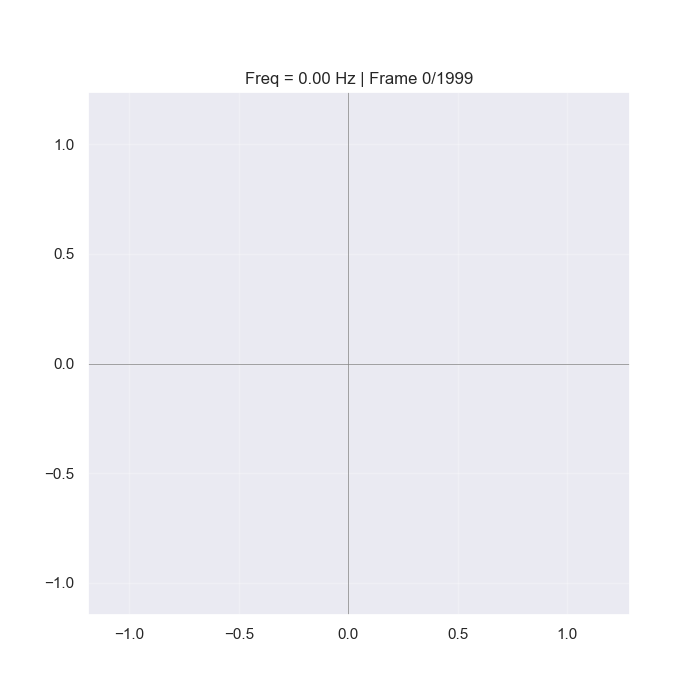

In [43]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import Play, IntSlider, HBox, VBox
from IPython.display import display

# ---- 计算全局坐标范围 ----
all_x = np.concatenate([np.array(x) for x in x_cord])
all_y = np.concatenate([np.array(y) for y in y_cord])
margin = 0.15 * max(all_x.max() - all_x.min(), all_y.max() - all_y.min(), 0.01)

# ---- 创建图形 ----
fig, ax = plt.subplots(figsize=(7, 7))
fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
ax.set_aspect('equal')
ax.grid(True, alpha=0.25)
ax.axhline(y=0, color='gray', lw=0.5)
ax.axvline(x=0, color='gray', lw=0.5)
ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
ax.set_ylim(all_y.min() - margin, all_y.max() + margin)

(line,) = ax.plot([], [], 'b-', lw=0.8)
(dot,)  = ax.plot([], [], 'ro', markersize=8)
title   = ax.set_title('', fontsize=12)

# ---- 控件：频率选择 + 帧播放 ----
freq_slider = IntSlider(value=0, min=0, max=len(sf_list)-1, step=1,
                        description='Freq #', style={'description_width': '60px'})
freq_label = widgets.Label(value=f'{sf_list[0]:.2f} Hz')

play = Play(value=0, min=0, max=len(t)-1, step=10, interval=40, description='▶')
frame_slider = IntSlider(value=0, min=0, max=len(t)-1, step=1,
                         description='Frame', style={'description_width': '60px'})
widgets.jslink((play, 'value'), (frame_slider, 'value'))

# ---- 更新回调 ----
def update(freq_idx, frame):
    l = freq_idx
    f = frame
    freq_label.value = f'{sf_list[l]:.2f} Hz'
    if f <= 1:
        line.set_data([], [])
        dot.set_data([], [])
    else:
        line.set_data(x_cord[l][:f], y_cord[l][:f])
        dot.set_data([np.mean(x_cord[l][:f])], [np.mean(y_cord[l][:f])])
    title.set_text(f'Freq = {sf_list[l]:.2f} Hz | Frame {f}/{len(t)-1}')

out = widgets.interactive_output(update, {'freq_idx': freq_slider, 'frame': frame_slider})

# ---- 界面 ----
ui = VBox([
    HBox([freq_slider, freq_label]),
    HBox([play, frame_slider]),
    out
])
display(ui)

In [44]:
plt.rcParams["figure.figsize"] = (12,4)
plt.xlabel("Frequeny (in Hz)")
plt.xticks(np.arange(min(sf_list), max(sf_list), 0.5))
sns.set()
plt.plot(sf_list,mean_list);

For clear estimation of Frequencies present, we need to smoothen the graph.<br>
Below is the smoothened version of the graph, showing that the energy is concentrated near 0 Hz and decays as frequency increases, which is characteristic of an exponential decay signal.

In [45]:
plt.rcParams["figure.figsize"] = (12,4)
smoothed = [i if i>0 and i>0.2*max(mean_list) else 0 for i in mean_list]
plt.plot(sf_list, smoothed)
plt.xlabel("Frequeny (in Hz)")
plt.xticks(np.arange(min(sf_list), max(sf_list), 0.5));

Plotting the same graph as a Bar chart, as the Frequencies are depicted in a typical Fourier Analysis

In [ ]:
plt.rcParams["figure.figsize"] = (12,4)
plt.xticks(np.arange(min(sf_list), max(sf_list), 0.5))
plt.xlabel("Frequeny (in Hz)")
plt.bar(sf_list, smoothed, width = 0.06); 